# L08 - Regulisers

### Qa The Penalty Factor
We have to construct a penalty function that implements $\mathbf{w}^\top \mathbf{w}$, re-using any function from `numpy`.

To solve this problem we merely use numpys dot function as: ```np.dot(w[1:], w[1:])```. This formulation avoids the bias term as is desired.

When the penalty is low, the non-bias weights are small or close to zero. While a high penalty means one or more non-bias weight is large.


In [3]:
# Qa..first define some numeric helper functions for the test-vectors..

import numpy as np
import collections
from collections.abc import Iterable

def isFloat(x):
    # is there a python single/double float??
    return isinstance(x, float) or isinstance(x, np.float32) or isinstance(x, np.float64)
    # NOT defined on Windows?:   or isinstance(x, np.float128)      

# Checks that a 'float' is 'sane' (original from libitmal)
def CheckFloat(x, checkrange=False, xmin=1E-200, xmax=1E200, verbose=0):
    if verbose>1:
        print(f"CheckFloat({x}, type={type(x)}")
    if isinstance(x, Iterable):
        for i in x:
            CheckFloat(i, checkrange=checkrange, xmin=xmin, xmax=xmax, verbose=verbose)
    else:
        #if (isinstance(x,int)):
        #    print("you gave me an integer, that was ignored")
        #    return
        assert isFloat(x), f"x={x} is not a float/float64/numpy.float32/64/128, but a {type(x)}"
        assert np.isnan(x)==False , "x is NAN"
        assert np.isinf(x)==False , "x is inf"
        assert np.isinf(-x)==False, "x is -inf"
        # NOTE: missing test for denormalized float
        if checkrange:
            z=fabs(x)
            assert z>=xmin, f"abs(x)={z} is smaller that expected min value={xmin}"
            assert z<=xmax, f"abs(x)={z} is larger that expected max value={xmax}"
        if verbose>0:
             print(f"CheckFloat({x}, type={x} => OK")

# Checks that two 'floats' are 'close' (original from libitmal)
def CheckInRange(x, expected, eps=1E-9, autoconverttofloat=True, verbose=0):
    assert eps>=0, "eps is less than zero"
    if autoconverttofloat and (not isFloat(x) or not isFloat(expected) or not isFloat(eps)):
        if verbose>1:
            print(f"notice: autoconverting x={x} to float..")
        return CheckInRange(1.0*x, 1.0*expected, 1.0*eps, False, verbose)
    CheckFloat(x)
    CheckFloat(expected)
    CheckFloat(eps)
    x0 = expected - eps
    x1 = expected + eps
    ok = x>=x0 and x<=x1
    absdiff = np.fabs(x-expected)
    if verbose > 0:
        print(f"CheckInRange(x={x}, expected={expected}, eps={eps}: x in [{x0}; {x1}] => {ok}")
    assert ok, f"x={x} is not within the range [{x0}; {x1}] for eps={eps}, got eps={absdiff}"

print("OK(setup..)")

OK(setup..)


In [4]:
# TODO: Qa - Penalty factor
    
def Omega(w):
    return np.dot(w[1:], w[1:])
 
# weight vector format: [w_0 w_1 .. w_d], ie. elem. 0 is the 'bias'    
w_a = np.array([1., 2., -3.])  
w_b = np.array([1E10, -3E10])
w_c = np.array([0.1, 0.2, -0.3, 0])

p_a = Omega(w_a)
p_b = Omega(w_b)
p_c = Omega(w_c)

print(f"P(w0)={p_a}")
print(f"P(w1)={p_b}")
print(f"P(w2)={p_c}")

# TEST VECTORS
e0 = 2*2+(-3)*(-3)
e1 = 9e+20
e2 = 0.13

CheckInRange(p_a, e0)
CheckInRange(p_b, e1)
CheckInRange(p_c, e2)

print("OK")

P(w0)=13.0
P(w1)=9e+20
P(w2)=0.13
OK


### Qb Explain the Ridge Plot
Explain what the different $\alpha$ does to the fitting for the `Ridge` model in the plot.

For the Ridge model the the $\alpha$ parameter controls the strenght of the penalty. When $\alpha$ increases the model is therefore punished more for having large weights. This generally makes the curve more smooth and less flexible.

This can also be seen from the resulting plots from the code below. 

When $\alpha=0$, the blue curve, we have no penalty and the fit is thus very wavy and reacts greatly to noise.

When $\alpha=10^{-5}$, the green curve, we have a very small penalty. This results in reduced oscillation and a more smooth curve compared to the blue curve but it is still generally somewhat wavy.

When $\alpha=1$, the red curve, we have much larger penalty making the curve much smoother and flatter compared to the blue and green curves. The curve no longer tries to track every point, which reduces the overfitting but can also results in underfitting if it is too large.


C:\Users\nilas\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.744e+00, tolerance: 9.295e-04
  model = cd_fast.enet_coordinate_descent(
C:\Users\nilas\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.774e+00, tolerance: 9.295e-04
  model = cd_fast.enet_coordinate_descent(


OK(plot)


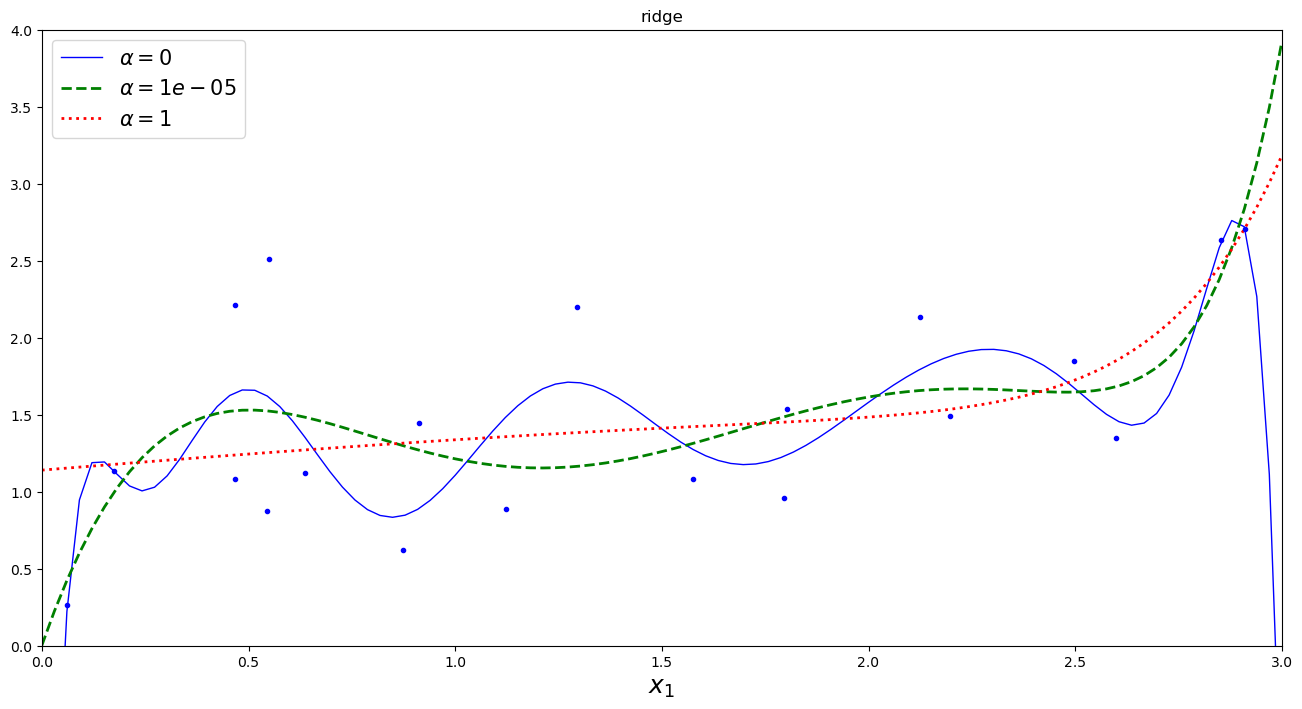

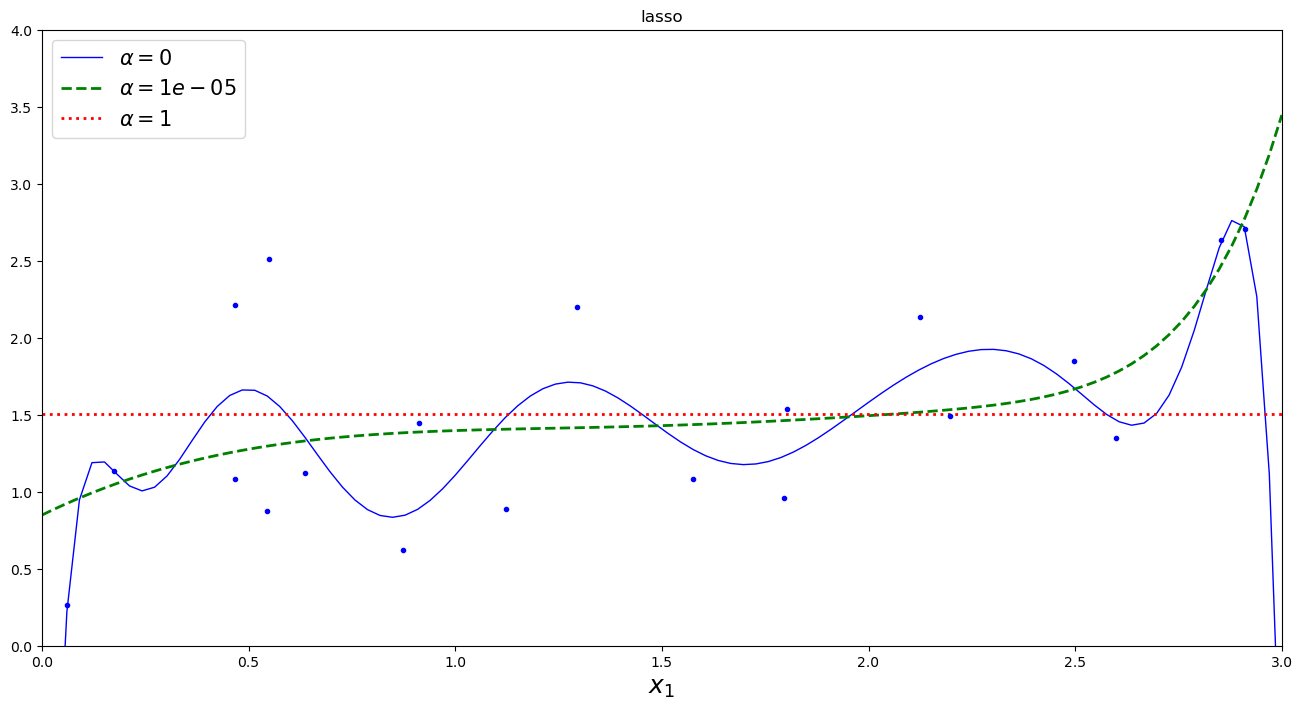

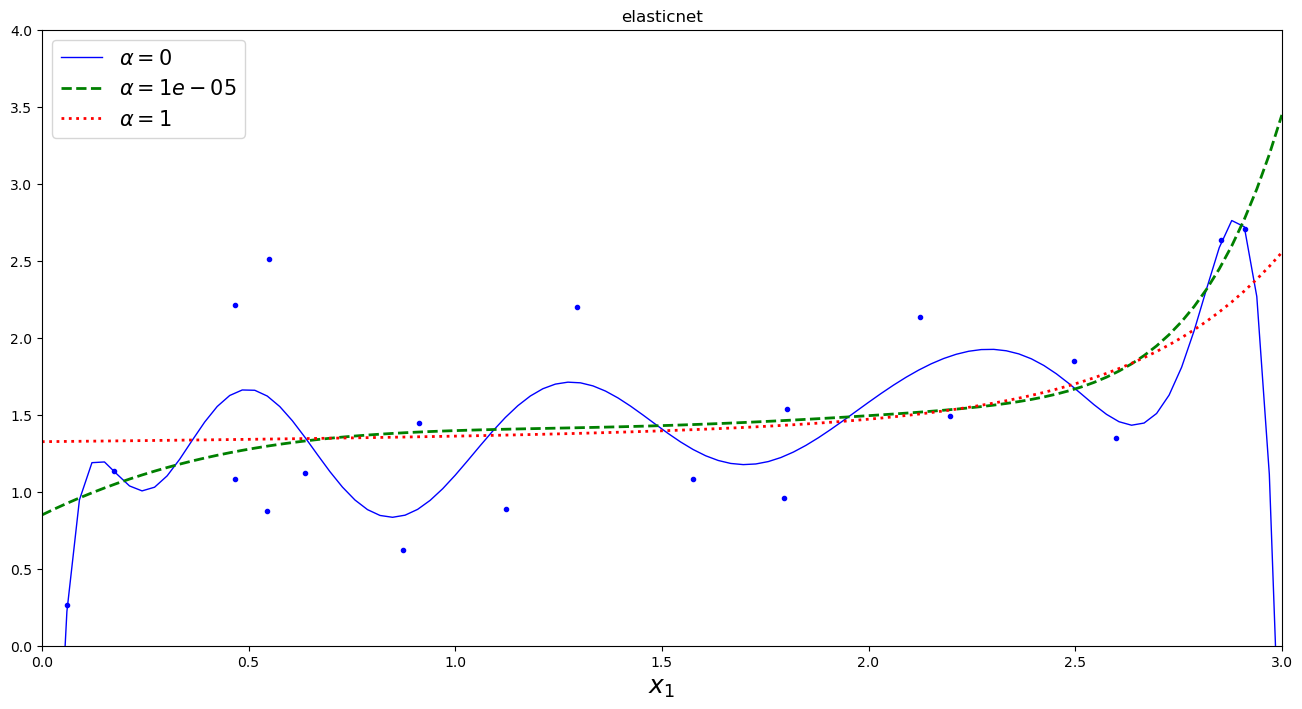

In [5]:
# TODO: Qb, just run the code..

%matplotlib inline

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, ElasticNet, Lasso

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def FitAndPlotModel(name, model_class, X, X_new, y, **model_kargs):
    plt.figure(figsize=(16,8))
    
    alphas=(0, 10**-5, 1) 
    random_state=42
    
    for alpha, style in zip(alphas, ("b-", "g--", "r:")):
        #print(model_kargs)
        model = model_class(alpha, **model_kargs) if alpha > 0 else LinearRegression()
        model_pipe = Pipeline([
                ("poly_features", PolynomialFeatures(degree=12, include_bias=False)),
                ("std_scaler", StandardScaler()),
                ("regul_reg", model),
            ])
            
        model_pipe.fit(X, y)
        y_new_regul = model_pipe.predict(X_new)
        
        lw = 2 if alpha > 0 else 1
        plt.plot(X_new, y_new_regul, style, linewidth=lw, label=r"$\alpha = {}$".format(alpha))
    
    plt.plot(X, y, "b.", linewidth=3)
    plt.legend(loc="upper left", fontsize=15)
    plt.xlabel("$x_1$", fontsize=18)
    plt.title(name)
    plt.axis([0, 3, 0, 4])

def GenerateData():
    np.random.seed(42)
    m = 20
    X = 3 * np.random.rand(m, 1)
    y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
    X_new = np.linspace(0, 3, 100).reshape(100, 1)
    return X, X_new, y
    
X, X_new, y = GenerateData()

FitAndPlotModel('ridge',      Ridge,        X, X_new, y)
FitAndPlotModel('lasso',      Lasso,        X, X_new, y)
FitAndPlotModel('elasticnet', ElasticNet,   X, X_new, y, l1_ratio=0.1)

print("OK(plot)")

### Qc Explain the Ridge, Lasso and ElasticNet Regularization Methods
We have to explain the different regularization methods for the `Ridge`, `Lasso` and `ElasticNet` models based on the math formulas and figure 4-19 below.

The Ridge model is a regularized version of the linear least square model with L2-norm regularization. The math formulation is defined as:

$J=\|y - Xw\|_2^2 + \alpha\|w\|_2^2$

Or the closed formed solution

$\hat{w} = \left(X^T X + \alpha A\right)^{-1} X^T y$

Where $\alpha$, as previously mentiond, is a parameter controlling the regularization strength.

In relation to figure 4-19, shown below, because Ridge uses a L2 penalty based on the squared size of the coefficients, the constraint region seen on the figure is round. When the Ridge then shrinks the coefficients towards zero, this smooth boundary results in an optimum where the coefficents are small but not quite zero.

The Lasso model, or Least Absolute Shrinkage and Selection Operator Regression, is a linear model with the L1-norm regularization. The Lasso model of scikit-learn optimizes:

$J=\frac{1}{2\,n_{\text{samples}}}\|y - Xw\|_2^2 + \alpha \|w\|_1$

Looking at figure 4-19, because Lasso uses L1 penalty the constraint region seen has corners which means it often reaches a point where some of the weights actually becomes zero, as it the case on the figure. This means it can often help produce simpler models by completely excluding some features.

The ElastisNet model combines L1 and L2 regularization and can thereby be considered a combination of Ridge and Lasso regularization. The model optimizes:

$J=\frac{1}{2n_{\text{samples}}}\,\lVert y - Xw \rVert_2^2
+ \alpha \cdot \mathrm{l1\_ratio} \cdot \lVert w \rVert_1
+ 0.5 \cdot \alpha \cdot (1 - \mathrm{l1\_ratio}) \cdot \lVert w \rVert_2^2$

Where $l1\_ratio$ is the ratio of L1 regularization to L2 regularization such that the degree of reguliarzation of each method can be controlled.

In relation to the figure, ElasticNet is a balance of the Ridge and Lasso models and therefore reaches a balance between feature selection and shrinkage.

<img src="https://itundervisning.ase.au.dk/SWMAL/L08-Regularisation/Figs/Screenshot_HOML_fig_4-19b.png" alt="WARNING: could not get image from server.">


REVISIONS||
:-|:-
2018-03-01| CEF, initial.
2018-03-06| CEF, updated.
2018-03-07| CEF, split Qb into Qb+c+d and added NN comment.
2018-03-11| CEF, updated Qa and $w_0$ issues.
2018-03-11| CEF, updated Qd with plot and Q.
2018-03-11| CEF, clarified $w_0$ issue and update $\tilde{J}$'s.
2019-10-15| CEF, updated for ITMAL E19.
2019-10-19| CEF, updated text, added float-check functions.
2020-03-23| CEF, updated to ITMAL F20.
2020-10-20| CEF, updated to ITMAL E20.
2020-10-27| CEF, minor updates.
2020-10-28| CEF, made preprocessing optional part of Qq (tug-of-war).
2020-03-17| CEF, updated to ITMAL F21.
2021-10-31| CEF, updated to ITMAL E21.
2022-03-31| CEF, updated to SWMAL F22.
2023-03-24| CEF, updated to SWMAL F23, added Qe.
2023-09-19| CEF, changed LaTeX mbox and newcommand (VSCode error) to textrm/mathrm and renewcommand.
2023-10-02| CEF, changed LaTeX commands to defs to get both KaTeX and MathJax to work.
2026-02-18| CEF, restored exercise, fixed image links, update math macros, update Qc, replaced tug-of-war with Fig 4-19.
2026-02-19| CEF, removed orphan tug-of-war Qd, moved Qe to Qd, added page numbers to fig 4.19. Replaced fig 4-19 with false color clone.